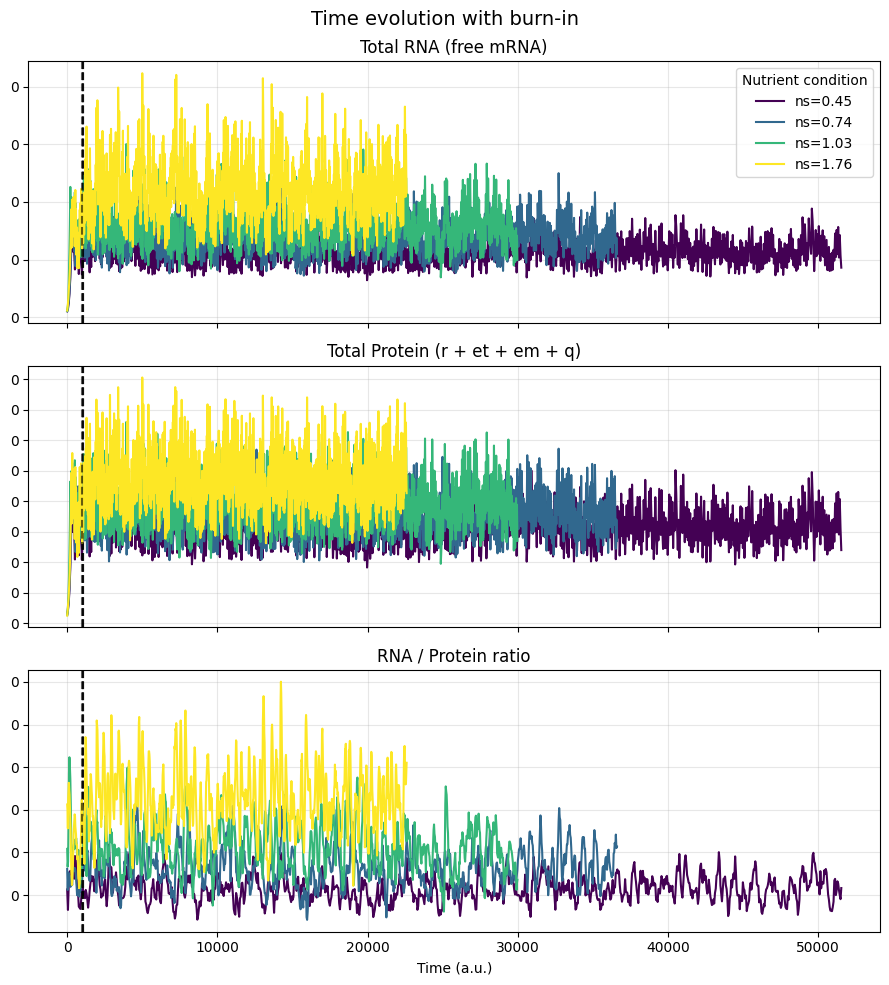

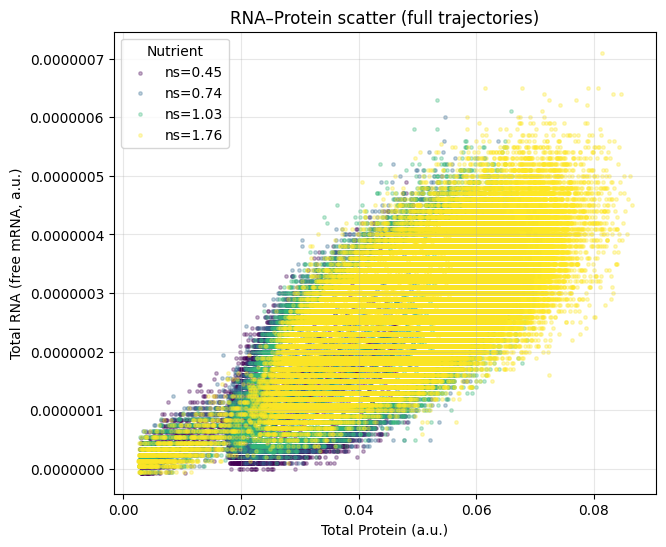

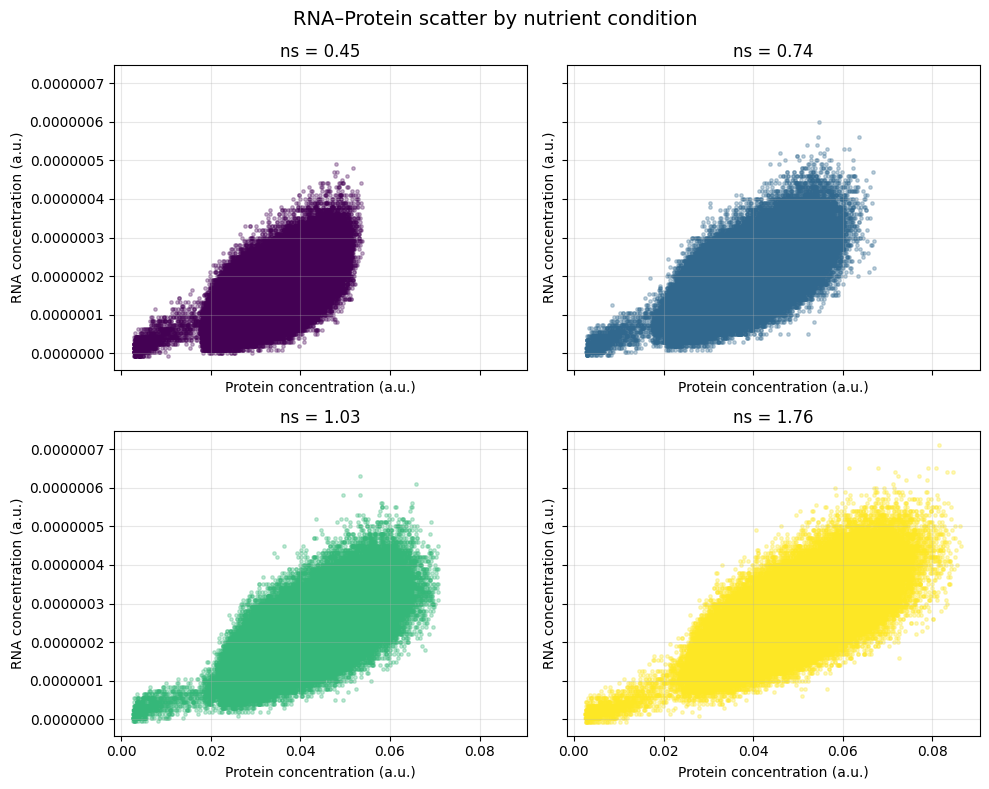

In [3]:
# =========================
# Main analysis + plots (one cell)
# =========================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pyarrow as pa
import pyarrow.ipc as ipc

# ---------- CONFIG ----------
FILES_WITH_NS = [
    ("Data/ns045.arrow", 0.45),
    ("Data/ns074.arrow", 0.74),
    ("Data/ns103.arrow", 1.03),
    ("Data/ns176.arrow", 1.76),
]
BURN_IN_TIME = 1000      # fixed burn-in time (a.u.)
N_RESAMPLE   = 1000        # uniform samples for smoothing/consistent stats
COLORS = plt.cm.viridis(np.linspace(0, 1, len(FILES_WITH_NS)))

# global formatting: plain numbers on axes
plt.rcParams['axes.formatter.useoffset'] = False
plt.rcParams['axes.formatter.use_mathtext'] = False

# ---------- REUSABLE HELPERS ----------
def read_arrow(filename: str) -> pd.DataFrame:
    with pa.memory_map(filename, "r") as src:
        return pa.ipc.open_file(src).read_all().to_pandas()

def total_rna(df: pd.DataFrame, include_bound: bool = False, include_stalled: bool = False) -> np.ndarray:
    """Total RNA. 
    include_bound=True adds translating mRNAs (rmr, rmt, rmm, rmq).
    include_stalled=True adds stalled complexes (zmr, zmt, zmm, zmq).
    """
    out = np.zeros(len(df))
    free = ["mr(t)", "mt(t)", "mm(t)", "mq(t)"]
    bound = ["r(t), rmr(t)", "rmt(t)", "rmm(t)", "rmq(t)"]
    stalled = ["zmr(t)", "zmt(t)", "zmm(t)", "zmq(t)"]
    for c in free:
        if c in df: out += df[c].values/1e8
    if include_bound:
        for c in bound:
            if c in df: out += df[c].values/1e8
    if include_stalled:
        for c in stalled:
            if c in df: out += df[c].values/1e8
    return out

def total_protein(df: pd.DataFrame) -> np.ndarray:
    """Total mature protein mass: ribosomes + transport + metabolic + housekeeping."""
    out = np.zeros(len(df))
    for c in ["r(t)", "et(t)", "em(t)", "q(t)"]:
        if c in df: out += df[c].values/1e8
    return out

def rna_protein_ratio(rna: np.ndarray, prot: np.ndarray) -> np.ndarray:
    return np.divide(rna, prot, out=np.zeros_like(rna), where=prot > 0)

def resample_uniform(t: np.ndarray, *series: np.ndarray, n: int = N_RESAMPLE):
    """Linear interpolation to a uniform time grid of length n."""
    t_new = np.linspace(t.min(), t.max(), n)
    out = [np.interp(t_new, t, s) for s in series]
    return (t_new, *out)

def steady_state_mean_std(t: np.ndarray, x: np.ndarray, burn_in_time: float = BURN_IN_TIME):
    """Mean, std, and the time index where steady-state starts (t >= burn_in)."""
    k0 = np.searchsorted(t, burn_in_time)
    k0 = min(k0, len(t) - 1)
    xs = x[k0:]
    return float(xs.mean()), float(xs.std()), t[k0]

def _beautify_axes(ax, ylabel=None):
    if ylabel:
        ax.set_ylabel(ylabel)
    ax.grid(alpha=0.3)
    ax.ticklabel_format(style='plain', axis='y')
    ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))

# ---------- 1) TIME SERIES WITH BURN-IN ----------
def plot_time_series_with_burnin(files_with_ns=FILES_WITH_NS):
    fig, axes = plt.subplots(3, 1, figsize=(9, 10), sharex=True)
    for (fname, ns), color in zip(files_with_ns, COLORS):
        df = read_arrow(fname)
        t = df["timestamp"].values
        # totals using standard definitions
        rna_free = total_rna(df, include_bound=True, include_stalled=True)
        prot     = total_protein(df)
        ratio    = rna_protein_ratio(rna_free, prot)

        # uniform resampling
        t_r, rna_r, prot_r, ratio_r = resample_uniform(t, rna_free, prot, ratio)

        # stats & plot
        _, _, t_burn = steady_state_mean_std(t_r, prot_r)
        axes[0].plot(t_r, rna_r, color=color, label=f"ns={ns}")
        axes[1].plot(t_r, prot_r, color=color)
        axes[2].plot(t_r, ratio_r, color=color)
        for ax in axes:
            ax.axvline(t_burn, color="black", ls="--", alpha=0.6)

    axes[0].set_title("Total RNA (free mRNA)")
    axes[1].set_title("Total Protein (r + et + em + q)")
    axes[2].set_title("RNA / Protein ratio")
    for ax in axes:
        _beautify_axes(ax)
    axes[-1].set_xlabel("Time (a.u.)")
    axes[0].legend(title="Nutrient condition")
    fig.suptitle(f"Time evolution with burn-in", fontsize=14)
    plt.tight_layout()
    plt.show()

# ---------- 2) RNA–PROTEIN SCATTER (ALL NS, FULL TRAJ) ----------
def plot_scatter_all(files_with_ns=FILES_WITH_NS):
    plt.figure(figsize=(7, 6))
    for (fname, ns), color in zip(files_with_ns, COLORS):
        df = read_arrow(fname)
        RNA = total_rna(df, include_bound=False, include_stalled=False)
        PROT = total_protein(df)
        plt.scatter(PROT, RNA, s=6, alpha=0.3, color=color, label=f"ns={ns:.2f}")
    plt.xlabel("Total Protein (a.u.)")
    plt.ylabel("Total RNA (free mRNA, a.u.)")
    plt.title("RNA–Protein scatter (full trajectories)")
    plt.grid(alpha=0.3)
    plt.legend(title="Nutrient")
    plt.gca().ticklabel_format(style='plain', axis='both')
    plt.show()

# ---------- 3) RNA–PROTEIN SCATTER PER-NS (NO LINES) ----------
def plot_scatter_per_ns(files_with_ns=FILES_WITH_NS):
    fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)
    axes = axes.flatten()
    for ax, ((fname, ns), color) in zip(axes, zip(files_with_ns, COLORS)):
        df = read_arrow(fname)
        RNA = total_rna(df, include_bound=False, include_stalled=False)
        PROT = total_protein(df)
        ax.scatter(PROT, RNA, s=6, alpha=0.3, color=color)
        ax.set_title(f"ns = {ns:.2f}")
        ax.set_xlabel("Protein concentration (a.u.)")
        ax.set_ylabel("RNA concentration (a.u.)")
        ax.grid(alpha=0.3)
        ax.ticklabel_format(style='plain', axis='both')
    fig.suptitle("RNA–Protein scatter by nutrient condition", fontsize=14)
    plt.tight_layout()
    plt.show()


# =========================
# RUN THE MAIN FIGURES
# =========================
plot_time_series_with_burnin(FILES_WITH_NS)
plot_scatter_all(FILES_WITH_NS)
plot_scatter_per_ns(FILES_WITH_NS)
# plot_rna_free_vs_bound(FILES_WITH_NS, include_stalled=True)  # set False to exclude z-terms


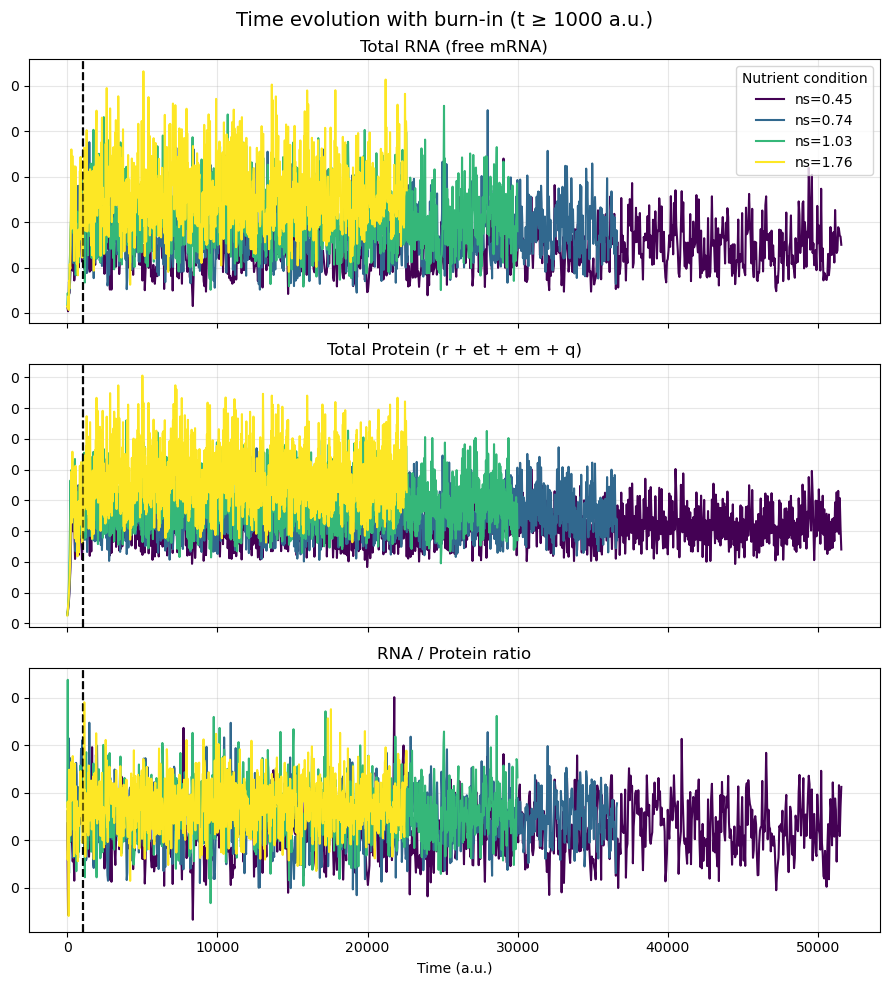

/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


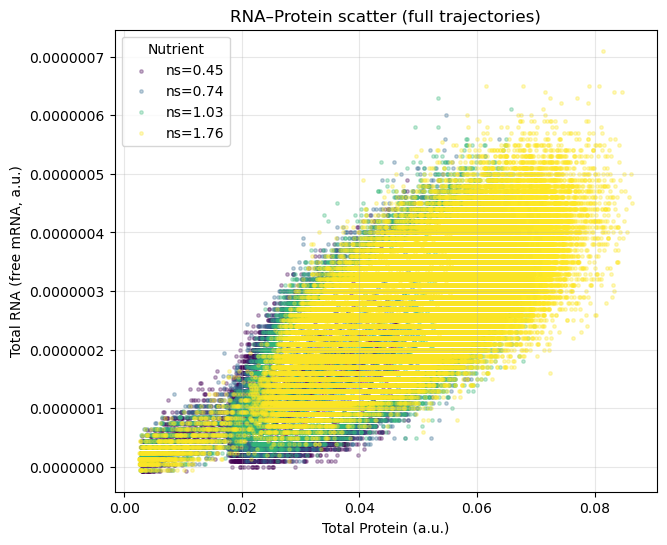

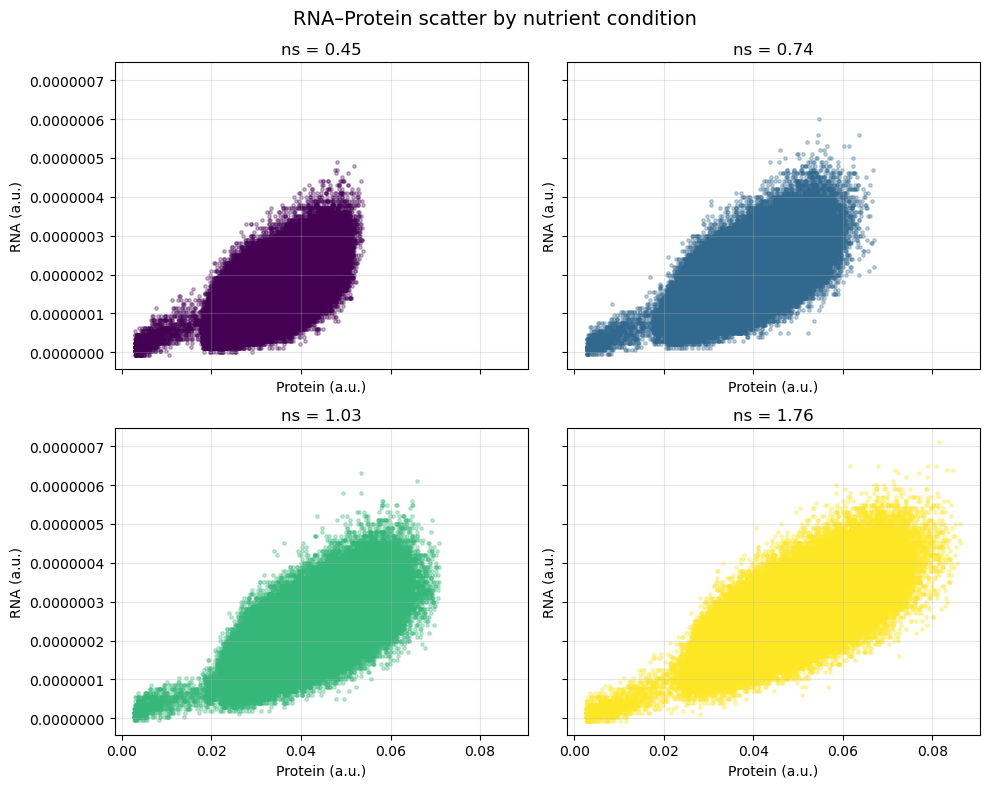

AttributeError: This method only works with the ScalarFormatter

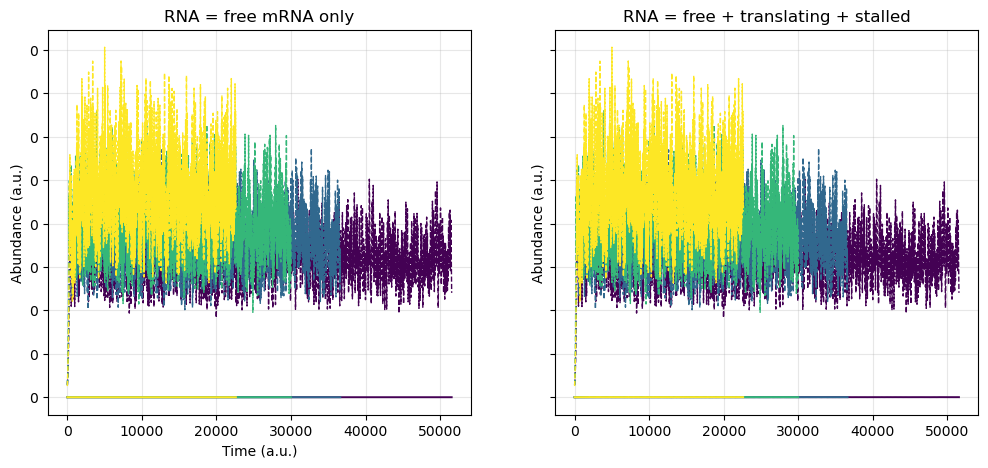

In [ ]:
# =========================
# Main analysis + plots (one cell)
# =========================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pyarrow as pa
import pyarrow.ipc as ipc

# ---------- CONFIG ----------
FILES_WITH_NS = [
    ("ns045.arrow", 0.45),
    ("ns074.arrow", 0.74),
    ("ns103.arrow", 1.03),
    ("ns176.arrow", 1.76),
]
BURN_IN_TIME = 1000      # fixed burn-in time (a.u.)
N_RESAMPLE   = 1000        # uniform samples for smoothing/consistent stats
COLORS = plt.cm.viridis(np.linspace(0, 1, len(FILES_WITH_NS)))

# global formatting: plain numbers on axes
plt.rcParams['axes.formatter.useoffset'] = False
plt.rcParams['axes.formatter.use_mathtext'] = False

# ---------- REUSABLE HELPERS ----------
def read_arrow(filename: str) -> pd.DataFrame:
    with pa.memory_map(filename, "r") as src:
        return pa.ipc.open_file(src).read_all().to_pandas()

def total_rna(df: pd.DataFrame, include_bound: bool = False, include_stalled: bool = False) -> np.ndarray:
    """Total RNA. 
    include_bound=True adds translating mRNAs (rmr, rmt, rmm, rmq).
    include_stalled=True adds stalled complexes (zmr, zmt, zmm, zmq).
    """
    out = np.zeros(len(df))
    free = ["mr(t)", "mt(t)", "mm(t)", "mq(t)"]
    bound = ["r(t), rmr(t)", "rmt(t)", "rmm(t)", "rmq(t)"]
    stalled = ["zmr(t)", "zmt(t)", "zmm(t)", "zmq(t)"]
    for c in free:
        if c in df: out += df[c].values/1e8
    if include_bound:
        for c in bound:
            if c in df: out += df[c].values/1e8
    if include_stalled:
        for c in stalled:
            if c in df: out += df[c].values/1e8
    return out

def total_protein(df: pd.DataFrame) -> np.ndarray:
    """Total mature protein mass: ribosomes + transport + metabolic + housekeeping."""
    out = np.zeros(len(df))
    for c in ["r(t)", "et(t)", "em(t)", "q(t)"]:
        if c in df: out += df[c].values/1e8
    return out

# def rna_protein_ratio(rna: np.ndarray, prot: np.ndarray) -> np.ndarray:
#     return np.divide(rna, prot, out=np.zeros_like(rna), where=prot > 0)
def rna_protein_ratio(rna, prot):
    ratio = rna / prot
    ratio[np.isnan(ratio)] = 0.0
    return ratio

def resample_uniform(t: np.ndarray, *series: np.ndarray, n: int = N_RESAMPLE):
    """Linear interpolation to a uniform time grid of length n."""
    t_new = np.linspace(t.min(), t.max(), n)
    out = [np.interp(t_new, t, s) for s in series]
    return (t_new, *out)

def steady_state_mean_std(t: np.ndarray, x: np.ndarray, burn_in_time: float = BURN_IN_TIME):
    """Mean, std, and the time index where steady-state starts (t >= burn_in)."""
    k0 = np.searchsorted(t, burn_in_time)
    k0 = min(k0, len(t) - 1)
    xs = x[k0:]
    return float(xs.mean()), float(xs.std()), t[k0]

def _beautify_axes(ax, ylabel=None):
    if ylabel:
        ax.set_ylabel(ylabel)
    ax.grid(alpha=0.3)
    ax.ticklabel_format(style='plain', axis='y')
    ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))

# ---------- 1) TIME SERIES WITH BURN-IN ----------
def plot_time_series_with_burnin(files_with_ns=FILES_WITH_NS):
    fig, axes = plt.subplots(3, 1, figsize=(9, 10), sharex=True)
    for (fname, ns), color in zip(files_with_ns, COLORS):
        df = read_arrow(fname)
        t = df["timestamp"].values
        # totals using standard definitions
        rna_free = total_rna(df, include_bound=False, include_stalled=False)
        prot     = total_protein(df)
        ratio    = rna_protein_ratio(rna_free, prot)

        # uniform resampling
        t_r, rna_r, prot_r, ratio_r = resample_uniform(t, rna_free, prot, ratio)

        # stats & plot
        _, _, t_burn = steady_state_mean_std(t_r, prot_r)
        axes[0].plot(t_r, rna_r, color=color, label=f"ns={ns}")
        axes[1].plot(t_r, prot_r, color=color)
        axes[2].plot(t_r, ratio_r, color=color)
        for ax in axes:
            ax.axvline(t_burn, color="black", ls="--", alpha=0.6)

    axes[0].set_title("Total RNA (free mRNA)")
    axes[1].set_title("Total Protein (r + et + em + q)")
    axes[2].set_title("RNA / Protein ratio")
    for ax in axes:
        _beautify_axes(ax)
    axes[-1].set_xlabel("Time (a.u.)")
    axes[0].legend(title="Nutrient condition")
    fig.suptitle(f"Time evolution with burn-in (t ≥ {BURN_IN_TIME} a.u.)", fontsize=14)
    plt.tight_layout()
    plt.show()

# ---------- 2) RNA–PROTEIN SCATTER (ALL NS, FULL TRAJ) ----------
def plot_scatter_all(files_with_ns=FILES_WITH_NS):
    plt.figure(figsize=(7, 6))
    for (fname, ns), color in zip(files_with_ns, COLORS):
        df = read_arrow(fname)
        RNA = total_rna(df, include_bound=False, include_stalled=False)
        PROT = total_protein(df)
        plt.scatter(PROT, RNA, s=6, alpha=0.3, color=color, label=f"ns={ns:.2f}")
    plt.xlabel("Total Protein (a.u.)")
    plt.ylabel("Total RNA (free mRNA, a.u.)")
    plt.title("RNA–Protein scatter (full trajectories)")
    plt.grid(alpha=0.3)
    plt.legend(title="Nutrient")
    plt.gca().ticklabel_format(style='plain', axis='both')
    plt.show()

# ---------- 3) RNA–PROTEIN SCATTER PER-NS (NO LINES) ----------
def plot_scatter_per_ns(files_with_ns=FILES_WITH_NS):
    fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)
    axes = axes.flatten()
    for ax, ((fname, ns), color) in zip(axes, zip(files_with_ns, COLORS)):
        df = read_arrow(fname)
        RNA = total_rna(df, include_bound=False, include_stalled=False)
        PROT = total_protein(df)
        ax.scatter(PROT, RNA, s=6, alpha=0.3, color=color)
        ax.set_title(f"ns = {ns:.2f}")
        ax.set_xlabel("Protein (a.u.)")
        ax.set_ylabel("RNA (a.u.)")
        ax.grid(alpha=0.3)
        ax.ticklabel_format(style='plain', axis='both')
    fig.suptitle("RNA–Protein scatter by nutrient condition", fontsize=14)
    plt.tight_layout()
    plt.show()

# ---------- 4) SIDE-BY-SIDE: RNA (FREE) vs RNA (FREE+BOUND [+STALLED]) ----------
def plot_rna_free_vs_bound(files_with_ns=FILES_WITH_NS, include_stalled=True):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
    titles = ["RNA = free mRNA only", "RNA = free + translating" + (" + stalled" if include_stalled else "")]
    for (fname, ns), color in zip(files_with_ns, COLORS):
        df = read_arrow(fname)
        t = df["timestamp"].values

        # compute variants
        rna_free = total_rna(df, include_bound=False, include_stalled=False)
        rna_ext  = total_rna(df, include_bound=True, include_stalled=include_stalled)
        prot     = total_protein(df)

        # resample for smooth overlay
        t_r, rnaF_r, prot_r = resample_uniform(t, rna_free, prot)
        _,    rnaX_r, _     = resample_uniform(t, rna_ext,  prot)

        # left: Free RNA vs Protein (dashed)
        axes[0].plot(t_r, rnaF_r, color=color, lw=1.4, label=f"RNA ns={ns}")
        axes[0].plot(t_r, prot_r, color=color, lw=1.0, ls="--", label=f"Protein ns={ns}")

        # right: Free+Bound(+Stalled) RNA vs same Protein
        axes[1].plot(t_r, rnaX_r, color=color, lw=1.4, label=f"RNA ns={ns}")
        axes[1].plot(t_r, prot_r, color=color, lw=1.0, ls="--", label=f"Protein ns={ns}")

    for ax, title in zip(axes, titles):
        ax.set_title(title)
        _beautify_axes(ax, ylabel="Abundance (a.u.)")
        ax.set_xlabel("Time (a.u.)")
    axes[0].legend(title="Nutrient", fontsize=8, ncol=2)
    fig.suptitle("RNA (free) vs RNA (free+translating[+stalled]) with Protein", fontsize=14)
    plt.tight_layout()
    plt.show()

# =========================
# RUN THE MAIN FIGURES
# =========================
plot_time_series_with_burnin(FILES_WITH_NS)
plot_scatter_all(FILES_WITH_NS)
plot_scatter_per_ns(FILES_WITH_NS)
plot_rna_free_vs_bound(FILES_WITH_NS, include_stalled=True)  # set False to exclude z-terms


In [ ]:
# === Variance, mean, noise (CV) analysis with subsampling ===

import numpy as np
import pandas as pd
import random

def compute_noise_metrics(files_with_ns, burn_in_time=1000, subsample_n=50000):
    results = []
    for fname, ns in files_with_ns:
        df = read_arrow(fname)
        t = df["timestamp"].values
        burn_in_time = 1000
        
        # Compute totals
        RNA = total_rna(df, include_bound=True, include_stalled=True)
        PROT = total_protein(df)
        Ratio = rna_protein_ratio(RNA, PROT)

        # Keep only post–burn-in region
        mask = t >= burn_in_time
        RNA, PROT, Ratio = RNA[mask], PROT[mask], Ratio[mask]

        # Subsampling (random indices)
        if len(RNA) > subsample_n:
            idx = random.sample(range(len(RNA)), subsample_n)
            RNA, PROT, Ratio = RNA[idx], PROT[idx], Ratio[idx]

        def stats(x):
            μ = np.mean(x)
            σ = np.std(x)
            var = np.var(x)
            return μ, var, σ/μ if μ != 0 else np.nan, var/μ if μ != 0 else np.nan

        μ_RNA, var_RNA, cv_RNA, fano_RNA = stats(RNA)
        μ_PROT, var_PROT, cv_PROT, fano_PROT = stats(PROT) # fano factor
        μ_RATIO, var_RATIO, cv_RATIO, fano_RATIO = stats(Ratio)

        results.append(dict(
            ns=ns,
            RNA_mean=μ_RNA, RNA_var=var_RNA, RNA_CV=cv_RNA, RNA_Fano=fano_RNA,
            Prot_mean=μ_PROT, Prot_var=var_PROT, Prot_CV=cv_PROT, Prot_Fano=fano_PROT,
            Ratio_mean=μ_RATIO, Ratio_var=var_RATIO, Ratio_CV=cv_RATIO, Ratio_Fano=fano_RATIO
        ))
    return pd.DataFrame(results)

# --- Run analysis ---
noise_df = compute_noise_metrics(FILES_WITH_NS, burn_in_time=BURN_IN_TIME, subsample_n=1000)
display(noise_df)


,ns,RNA_mean,RNA_var,RNA_CV,RNA_Fano,Prot_mean,Prot_var,Prot_CV,Prot_Fano,Ratio_mean,Ratio_var,Ratio_CV,Ratio_Fano
0,0.45,0.000011,6.364028e-12,0.223326,5.633852e-07,0.031666,0.000048,0.218277,0.001509,0.000357,2.164456e-10,0.041250,6.068685e-07
1,0.74,0.000014,1.172418e-11,0.245983,8.422597e-07,0.036290,0.000069,0.229561,0.001912,0.000383,4.869158e-10,0.057634,1.271758e-06
2,1.03,0.000016,1.626074e-11,0.250292,1.009293e-06,0.039409,0.000081,0.228062,0.002050,0.000408,8.027729e-10,0.069477,1.968508e-06
3,1.76,0.000022,3.479562e-11,0.262392,1.547794e-06,0.048163,0.000118,0.225916,0.002458,0.000464,1.553168e-09,0.084848,3.343874e-06


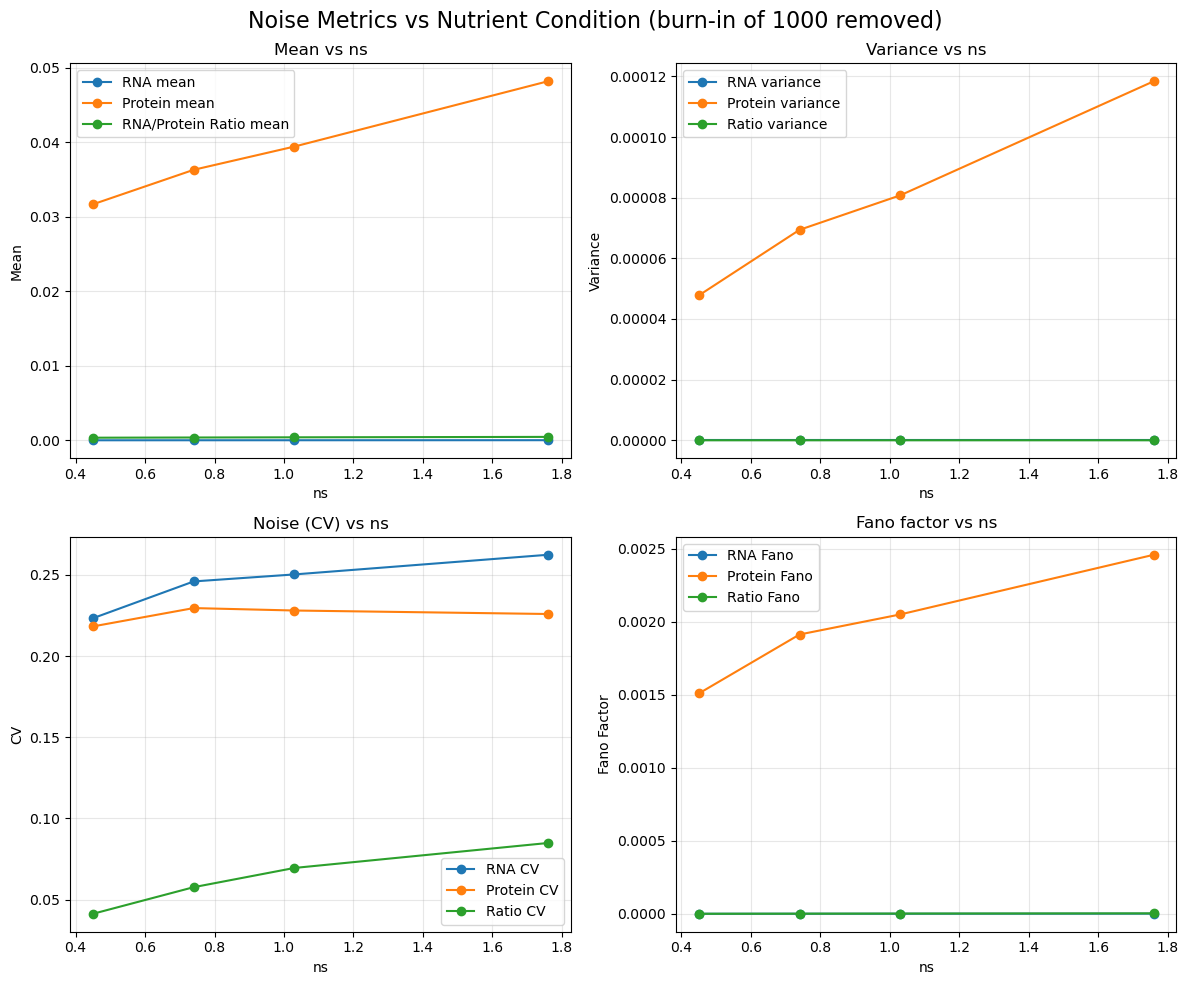

In [ ]:
import matplotlib.pyplot as plt

def plot_noise_metrics(noise_df):
    ns_vals = noise_df["ns"].values

    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    axes = axes.flatten()

    # --- 1. Mean vs ns ---
    axes[0].plot(ns_vals, noise_df["RNA_mean"], '-o', label="RNA mean")
    axes[0].plot(ns_vals, noise_df["Prot_mean"], '-o', label="Protein mean")
    axes[0].plot(ns_vals, noise_df["Ratio_mean"], '-o', label="RNA/Protein Ratio mean")
    axes[0].set_title("Mean vs ns")
    axes[0].set_xlabel("ns")
    axes[0].set_ylabel("Mean")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # --- 2. Variance vs ns ---
    axes[1].plot(ns_vals, noise_df["RNA_var"], '-o', label="RNA variance")
    axes[1].plot(ns_vals, noise_df["Prot_var"], '-o', label="Protein variance")
    axes[1].plot(ns_vals, noise_df["Ratio_var"], '-o', label="Ratio variance")
    axes[1].set_title("Variance vs ns")
    axes[1].set_xlabel("ns")
    axes[1].set_ylabel("Variance")
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    # --- 3. Coefficient of Variation (CV) ---
    axes[2].plot(ns_vals, noise_df["RNA_CV"], '-o', label="RNA CV")
    axes[2].plot(ns_vals, noise_df["Prot_CV"], '-o', label="Protein CV")
    axes[2].plot(ns_vals, noise_df["Ratio_CV"], '-o', label="Ratio CV")
    axes[2].set_title("Noise (CV) vs ns")
    axes[2].set_xlabel("ns")
    axes[2].set_ylabel("CV")
    axes[2].legend()
    axes[2].grid(alpha=0.3)

    # --- 4. Fano factor ---
    axes[3].plot(ns_vals, noise_df["RNA_Fano"], '-o', label="RNA Fano")
    axes[3].plot(ns_vals, noise_df["Prot_Fano"], '-o', label="Protein Fano")
    axes[3].plot(ns_vals, noise_df["Ratio_Fano"], '-o', label="Ratio Fano")
    axes[3].set_title("Fano factor vs ns")
    axes[3].set_xlabel("ns")
    axes[3].set_ylabel("Fano Factor")
    axes[3].legend()
    axes[3].grid(alpha=0.3)

    fig.suptitle(f"Noise Metrics vs Nutrient Condition (burn-in of 1000 removed)", fontsize=16)

    plt.tight_layout()
    plt.show()

# Call it
plot_noise_metrics(noise_df)


In [ ]:
import numpy as np
import pandas as pd

def compute_noise_metrics_with_bootstrap(files_with_ns,
                                         burn_in_time=1000,
                                         subsample_n=1000,
                                         n_boot=500,
                                         random_state=None):
    rng = np.random.default_rng(random_state)
    results = []

    def stats(x):
        μ = np.mean(x)
        σ = np.std(x)
        var = np.var(x)
        cv = σ / μ if μ != 0 else np.nan
        fano = var / μ if μ != 0 else np.nan
        return μ, var, cv, fano

    def bootstrap_ci(x):
        n = len(x)
        means, vars_, cvs, fanos = [], [], [], []
        for _ in range(n_boot):
            idx = rng.integers(0, n, size=n)  # resample with replacement
            xb = x[idx]
            μ, var, cv, fano = stats(xb)
            means.append(μ)
            vars_.append(var)
            cvs.append(cv)
            fanos.append(fano)
        # 95% CI
        return (
            np.percentile(means, [2.5, 97.5]),
            np.percentile(vars_, [2.5, 97.5]),
            np.percentile(cvs, [2.5, 97.5]),
            np.percentile(fanos, [2.5, 97.5]),
        )

    for fname, ns in files_with_ns:
        df = read_arrow(fname)
        t = df["timestamp"].values

        # totals
        RNA = total_rna(df, include_bound=True, include_stalled=True)
        PROT = total_protein(df)
        Ratio = rna_protein_ratio(RNA, PROT)

        # burn-in removal
        mask = t >= burn_in_time
        RNA, PROT, Ratio = RNA[mask], PROT[mask], Ratio[mask]

        # subsample (without replacement, just like before)
        if len(RNA) > subsample_n:
            idx = rng.choice(len(RNA), subsample_n, replace=False)
            RNA, PROT, Ratio = RNA[idx], PROT[idx], Ratio[idx]

        # point estimates
        μ_RNA, var_RNA, cv_RNA, fano_RNA = stats(RNA)
        μ_PROT, var_PROT, cv_PROT, fano_PROT = stats(PROT)
        μ_RATIO, var_RATIO, cv_RATIO, fano_RATIO = stats(Ratio)

        # bootstrap CIs
        RNA_mean_ci, RNA_var_ci, RNA_cv_ci, RNA_fano_ci = bootstrap_ci(RNA)
        PROT_mean_ci, PROT_var_ci, PROT_cv_ci, PROT_fano_ci = bootstrap_ci(PROT)
        RATIO_mean_ci, RATIO_var_ci, RATIO_cv_ci, RATIO_fano_ci = bootstrap_ci(Ratio)

        results.append(dict(
            ns=ns,

            RNA_mean=μ_RNA,
            RNA_mean_lo=RNA_mean_ci[0], RNA_mean_hi=RNA_mean_ci[1],
            RNA_var=var_RNA,
            RNA_var_lo=RNA_var_ci[0], RNA_var_hi=RNA_var_ci[1],
            RNA_CV=cv_RNA,
            RNA_CV_lo=RNA_cv_ci[0], RNA_CV_hi=RNA_cv_ci[1],
            RNA_Fano=fano_RNA,
            RNA_Fano_lo=RNA_fano_ci[0], RNA_Fano_hi=RNA_fano_ci[1],

            Prot_mean=μ_PROT,
            Prot_mean_lo=PROT_mean_ci[0], Prot_mean_hi=PROT_mean_ci[1],
            Prot_var=var_PROT,
            Prot_var_lo=PROT_var_ci[0], Prot_var_hi=PROT_var_ci[1],
            Prot_CV=cv_PROT,
            Prot_CV_lo=PROT_cv_ci[0], Prot_CV_hi=PROT_cv_ci[1],
            Prot_Fano=fano_PROT,
            Prot_Fano_lo=PROT_fano_ci[0], Prot_Fano_hi=PROT_fano_ci[1],

            Ratio_mean=μ_RATIO,
            Ratio_mean_lo=RATIO_mean_ci[0], Ratio_mean_hi=RATIO_mean_ci[1],
            Ratio_var=var_RATIO,
            Ratio_var_lo=RATIO_var_ci[0], Ratio_var_hi=RATIO_var_ci[1],
            Ratio_CV=cv_RATIO,
            Ratio_CV_lo=RATIO_cv_ci[0], Ratio_CV_hi=RATIO_cv_ci[1],
            Ratio_Fano=fano_RATIO,
            Ratio_Fano_lo=RATIO_fano_ci[0], Ratio_Fano_hi=RATIO_fano_ci[1],
        ))

    return pd.DataFrame(results)



In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def _add_series_with_ci_fill(ax, ns_vals, df, prefix, label, color):
    mean = df[f"{prefix}_mean"].values
    lo   = df[f"{prefix}_mean_lo"].values
    hi   = df[f"{prefix}_mean_hi"].values

    ax.plot(ns_vals, mean, '-o', color=color, label=label)
    ax.fill_between(ns_vals, lo, hi, color=color, alpha=0.2)


def _add_metric_with_ci_fill(ax, ns_vals, df, col, lo_col, hi_col, label, color):
    y   = df[col].values
    lo  = df[lo_col].values
    hi  = df[hi_col].values

    ax.plot(ns_vals, y, '-o', color=color, label=label)
    ax.fill_between(ns_vals, lo, hi, color=color, alpha=0.2)


def plot_noise_metrics_with_ci_fill(df, log_scale=False):
    ns_vals = df["ns"].values

    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    axes = axes.flatten()

    colors = {
        "RNA":  "#1f77b4",   # blue
        "Prot": "#ff7f0e",   # orange
        "Ratio":"#2ca02c"    # green
    }

    # --- 1. Mean ---
    _add_series_with_ci_fill(axes[0], ns_vals, df, "RNA",   "RNA mean",               colors["RNA"])
    _add_series_with_ci_fill(axes[0], ns_vals, df, "Prot",  "Protein mean",           colors["Prot"])
    _add_series_with_ci_fill(axes[0], ns_vals, df, "Ratio", "RNA/Protein Ratio mean", colors["Ratio"])
    axes[0].set_title("Mean vs ns")
    axes[0].set_xlabel("ns"); axes[0].set_ylabel("Mean")
    axes[0].legend(); axes[0].grid(alpha=0.3)

    # --- 2. Variance ---
    _add_metric_with_ci_fill(axes[1], ns_vals, df,
                             "RNA_var","RNA_var_lo","RNA_var_hi","RNA variance", colors["RNA"])
    _add_metric_with_ci_fill(axes[1], ns_vals, df,
                             "Prot_var","Prot_var_lo","Prot_var_hi","Protein variance", colors["Prot"])
    _add_metric_with_ci_fill(axes[1], ns_vals, df,
                             "Ratio_var","Ratio_var_lo","Ratio_var_hi","Ratio variance", colors["Ratio"])
    axes[1].set_title("Variance vs ns")
    axes[1].set_xlabel("ns"); axes[1].set_ylabel("Variance")
    axes[1].legend(); axes[1].grid(alpha=0.3)

    # --- 3. CV ---
    _add_metric_with_ci_fill(axes[2], ns_vals, df,
                             "RNA_CV","RNA_CV_lo","RNA_CV_hi","RNA CV", colors["RNA"])
    _add_metric_with_ci_fill(axes[2], ns_vals, df,
                             "Prot_CV","Prot_CV_lo","Prot_CV_hi","Protein CV", colors["Prot"])
    _add_metric_with_ci_fill(axes[2], ns_vals, df,
                             "Ratio_CV","Ratio_CV_lo","Ratio_CV_hi","Ratio CV", colors["Ratio"])
    axes[2].set_title("Noise (CV) vs ns")
    axes[2].set_xlabel("ns"); axes[2].set_ylabel("CV")
    axes[2].legend(); axes[2].grid(alpha=0.3)

    # --- 4. Fano ---
    _add_metric_with_ci_fill(axes[3], ns_vals, df,
                             "RNA_Fano","RNA_Fano_lo","RNA_Fano_hi","RNA Fano", colors["RNA"])
    _add_metric_with_ci_fill(axes[3], ns_vals, df,
                             "Prot_Fano","Prot_Fano_lo","Prot_Fano_hi","Protein Fano", colors["Prot"])
    _add_metric_with_ci_fill(axes[3], ns_vals, df,
                             "Ratio_Fano","Ratio_Fano_lo","Ratio_Fano_hi","Ratio Fano", colors["Ratio"])
    axes[3].set_title("Fano factor vs ns")
    axes[3].set_xlabel("ns"); axes[3].set_ylabel("Fano")
    axes[3].legend(); axes[3].grid(alpha=0.3)

    # --- optional log scaling ---
    if log_scale:
        for ax in axes:
            ax.set_yscale("log")

    scale_label = "log scale" if log_scale else "linear scale"
    fig.suptitle(
        f"Noise Metrics vs Nutrient Condition (95% CI shaded, {scale_label})",
        fontsize=16
    )
    plt.tight_layout()
    plt.show()


In [ ]:
noise_boot_df = compute_noise_metrics_with_bootstrap(
    FILES_WITH_NS,
    burn_in_time=BURN_IN_TIME,
    subsample_n=1000,
    n_boot=500,
    random_state=0
)


In [ ]:
plot_noise_metrics_with_ci_fill(noise_boot_df)


In [ ]:
plot_noise_metrics_with_ci(noise_boot_df, log_scale=True)
plot_noise_metrics_with_ci_fill(noise_boot_df, log_scale=True)


In [ ]:
plt.figure(figsize=(6,4))
plt.plot(noise_df["ns"], noise_df["RNA_CV"], "o-", label="RNA")
plt.plot(noise_df["ns"], noise_df["Prot_CV"], "o-", label="Protein")
plt.plot(noise_df["ns"], noise_df["Ratio_CV"], "o-", label="RNA/Protein")
plt.xlabel("Nutrient strength (ns)")
plt.ylabel("Coefficient of variation (CV)")
plt.title("Noise vs nutrient richness")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pyarrow as pa
import pyarrow.ipc as ipc

# ---- Growth rate parameters ----
gmax = 1260.0
Kgamma = 7.0
M = 1e8

# ---- Read arrow helper ----
def read_arrow(fname):
    with pa.memory_map(fname, "r") as source:
        return pa.ipc.open_file(source).read_all().to_pandas()

# ---- Compute λ(t) ----
def compute_growth_rate(df):
    # active ribosomes
    active = (df["rmm(t)"] +
              df["rmt(t)"] +
              df["rmq(t)"] +
              df["rmr(t)"]).values

    a = df["a(t)"].values

    gamma = gmax * a / (Kgamma + a)
    lam = gamma * active / M

    return df["timestamp"].values, lam

# ---- Plot all nutrient conditions ----
plt.figure(figsize=(9,6))
colors = ["purple","blue","green","gold"]

for (fname, ns), color in zip(FILES_WITH_NS, colors):
    df = read_arrow(fname)
    t, lam = compute_growth_rate(df)
    plt.plot(t, lam, color=color, lw=2, label=f"ns={ns}")

plt.xlabel("Time (min)")
plt.ylabel("Growth rate λ(t) (1/time)")
plt.title("Stochastic growth rate over time for each nutrient condition")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyarrow as pa
import pyarrow.ipc as ipc

# ----- PARAMETERS (stochastic model) -----
GMAX   = 1260.0       # same as in your Julia model
KGAMMA = 7.0
MREF   = 1e8          # mass used in lam(...)
FILES_WITH_NS = [
    ("ns045.arrow", 0.45),
    ("ns074.arrow", 0.74),
    ("ns103.arrow", 1.03),
    ("ns176.arrow", 1.76),
]

# ----- BASIC IO -----
def read_arrow(filename: str) -> pd.DataFrame:
    """Read an Arrow file to a pandas DataFrame."""
    with pa.memory_map(filename, "r") as source:
        return pa.ipc.open_file(source).read_all().to_pandas()

# ----- LAMBDA (GROWTH RATE) FROM STOCHASTIC TRAJECTORY -----
def compute_lambda_from_df(df: pd.DataFrame,
                           gmax: float = GMAX,
                           Kgamma: float = KGAMMA,
                           M: float = MREF):
    """
    Compute λ(t) from a stochastic trajectory DataFrame using:
    λ(t) = gamma(a) * (rmm + rmt + rmq + rmr) / M
    """
    # active ribosome complexes (non-stalled)
    active = (df["rmm(t)"] +
              df["rmt(t)"] +
              df["rmq(t)"] +
              df["rmr(t)"]).to_numpy()

    a = df["a(t)"].to_numpy()
    gamma = gmax * a / (Kgamma + a)
    lam = gamma * active / M

    t = df["timestamp"].to_numpy()
    return t, lam

# ----- STEADY STATE SUMMARY -----
def steady_state_lambda(t, lam, frac_tail: float = 0.2):
    """
    Take the last frac_tail of the trajectory and compute
    mean and std of λ(t) as a 'steady-state' summary.
    """
    t = np.asarray(t)
    lam = np.asarray(lam)
    t_cut = t.min() + (t.max() - t.min()) * (1.0 - frac_tail)
    mask = t >= t_cut
    return lam[mask].mean(), lam[mask].std(), t_cut


In [ ]:
lambda_stats = sorted(lambda_stats, key=lambda x: x[0])  # sort by ns
ns_vals   = [x[0] for x in lambda_stats]
lam_means = [x[1] for x in lambda_stats]
lam_stds  = [x[2] for x in lambda_stats]

plt.figure(figsize=(6, 4))
plt.errorbar(ns_vals, lam_means, yerr=lam_stds,
             fmt="o-", capsize=4, lw=1.5)

plt.xlabel("Nutrient strength ns")
plt.ylabel("Steady-state growth rate ⟨λ⟩ (1/a.u.)")
plt.title("Stochastic growth law: λ vs ns")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


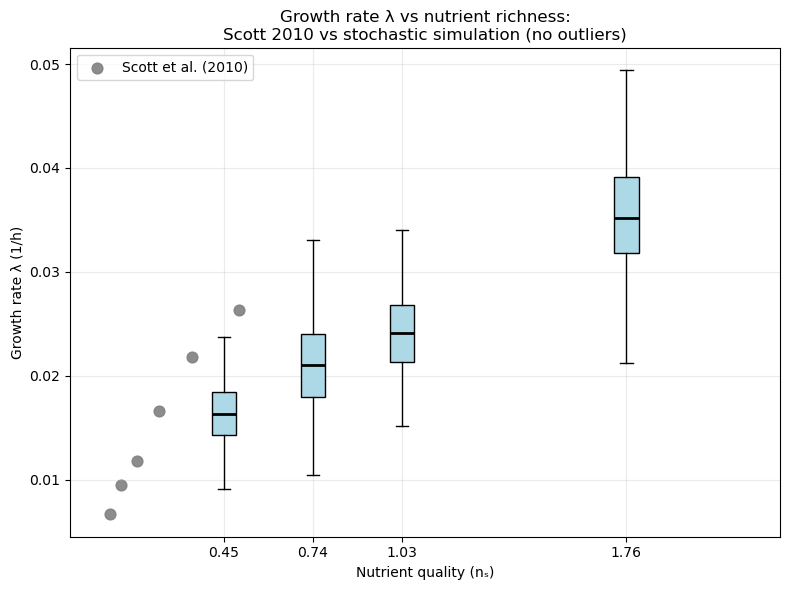

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# 1) Load Scott dataset
# ============================================================
scott = pd.read_csv("Scott_Data.csv")

# Keep drug-free conditions only
scott0 = scott[scott["cl"] == 0].copy()

# If nutrient-quality column exists, use it
if "ns" in scott0.columns:
    scott_ns = scott0["ns"].values
else:
    scott_ns = np.linspace(0.25, 1.0, len(scott0))

scott_lambda = scott0["lambda"].values

# ============================================================
# 2) Simulation data (already computed earlier)
# ============================================================
# sim_ns, sim_lambda_samples must exist:
#   sim_lambda_samples[ns_value] = array of λ(t) after burn-in

# Example fallback (delete when your real data exists)
try:
    sim_lambda_samples
except:
    sim_ns = np.array([0.45, 0.74, 1.03, 1.76])
    sim_lambda_samples = {
        0.45: np.random.normal(0.016, 0.003, 300),
        0.74: np.random.normal(0.021, 0.004, 300),
        1.03: np.random.normal(0.024, 0.004, 300),
        1.76: np.random.normal(0.035, 0.006, 300)
    }

# ============================================================
# 3) Boxplot + Scott data
# ============================================================
plt.figure(figsize=(8, 6))

# Scott 2010 (drug-free)
plt.scatter(scott_ns, scott_lambda, 
            color="gray", s=60, alpha=0.9, label="Scott et al. (2010)")

# Simulation as boxplots WITHOUT outliers
box_data = [sim_lambda_samples[ns] for ns in sim_ns]

plt.boxplot(
    box_data,
    positions=sim_ns,
    widths=0.08,
    patch_artist=True,
    showfliers=False,   # <---- REMOVE OUTLIERS
    boxprops=dict(facecolor="lightblue", color="black"),
    medianprops=dict(color="black", linewidth=2),
    whiskerprops=dict(color="black"),
    capprops=dict(color="black")
)

plt.xlabel("Nutrient quality (nₛ)")
plt.ylabel("Growth rate λ (1/h)")
plt.title("Growth rate λ vs nutrient richness:\nScott 2010 vs stochastic simulation (no outliers)")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout() 
plt.show()


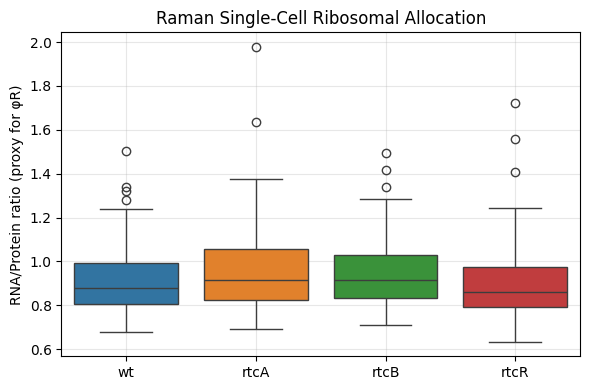

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

raman_file = "Raman_data.xlsx"
sheets = ["wt", "rtcA", "rtcB", "rtcR"]

raman_values = []
labels = []

for sheet in sheets:
    df = pd.read_excel(raman_file, sheet_name=sheet, header=None)
    df = df.set_index(0).T   # rows = cells
    if "RNA/Protein" in df.columns:
        ratio = df["RNA/Protein"].astype(float).values
    else:
        ratio = (df["RNA"].astype(float) / df["Protein"].astype(float)).values
    raman_values.append(ratio)
    labels.append(sheet)

plt.figure(figsize=(6,4))
sns.boxplot(data=raman_values)
plt.xticks(range(4), labels)
plt.ylabel("RNA/Protein ratio (proxy for φR)")
plt.title("Raman Single-Cell Ribosomal Allocation")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


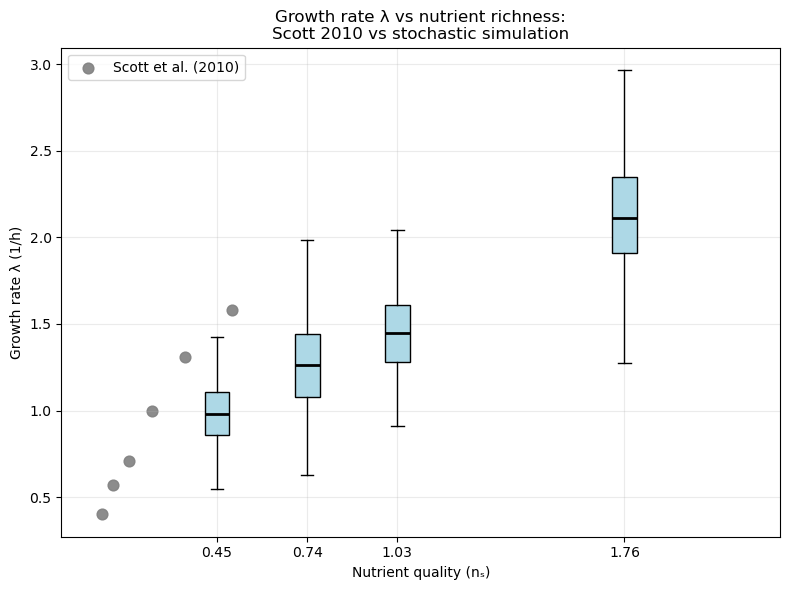

In [ ]:
scott_lambda = scott0["lambda"].values
scott_lambda = scott0["lambda"].values * 60   # Convert 1/min → 1/h

plt.figure(figsize=(8, 6))

# Scott 2010 (already in 1/h)
plt.scatter(scott_ns, scott_lambda, 
            color="gray", s=60, alpha=0.9, label="Scott et al. (2010)")

# Convert sim λ from 1/min → 1/hour
sim_lambda_samples_h = {ns: 60 * np.array(vals) for ns, vals in sim_lambda_samples.items()}

box_data = [sim_lambda_samples_h[ns] for ns in sim_ns]

plt.boxplot(
    box_data,
    positions=sim_ns,
    widths=0.08,
    patch_artist=True,
    showfliers=False,
    boxprops=dict(facecolor="lightblue", color="black"),
    medianprops=dict(color="black", linewidth=2),
    whiskerprops=dict(color="black"),
    capprops=dict(color="black")
)

plt.xlabel("Nutrient quality (nₛ)")
plt.ylabel("Growth rate λ (1/h)")
plt.title("Growth rate λ vs nutrient richness:\nScott 2010 vs stochastic simulation")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
print("Scott λ (should be in 1/h):", scott0["lambda"].head())


Scott λ (should be in 1/h): 0     0.006667
5     0.009500
10    0.011833
15    0.016667
20    0.021833
Name: lambda, dtype: float64


Scott fit: phi0=0.0515, kt=0.088  (r^2=0.966)


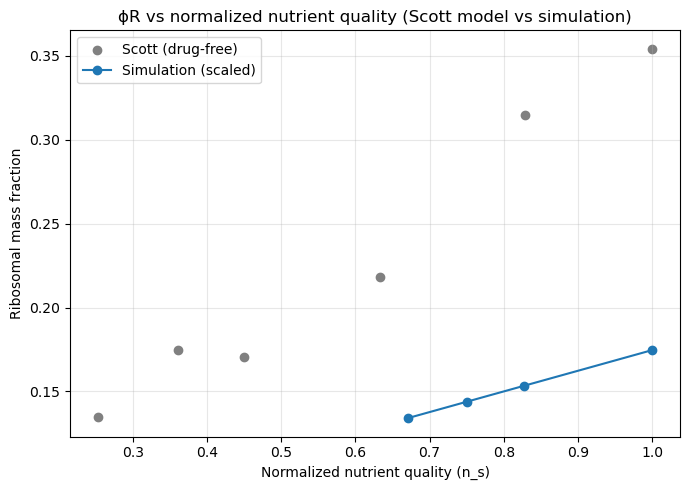

In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import linregress
import matplotlib.pyplot as plt

# Scott data: columns 'lambda' (1/h), 'fr' (phi_R), 'cl' (chloramphenicol)
scott = pd.read_csv("Scott_Data.csv")
scott_no_abx = scott[scott["cl"] == 0].copy()

# Fit Scott nutrient line: fr = phi0 + lambda/kt
fit = linregress(scott_no_abx["lambda"], scott_no_abx["fr"])
phi0, kt = fit.intercept, 1.0/fit.slope
print(f"Scott fit: phi0={phi0:.4f}, kt={kt:.3f}  (r^2={fit.rvalue**2:.3f})")

# Your simulation summary (already built earlier):
# noise_df with columns: ['ns','Ratio_mean']
sim_df = noise_df.copy()

# Scale your ratio to a mass-fraction proxy 
scale_factor = 376  
sim_df["phi_sim"] = scale_factor * sim_df["Ratio_mean"]

# Map your phi -> lambda_hat via Scott's law
sim_df["lambda_hat"] = kt * (sim_df["phi_sim"] - phi0)

# ---- Option 1: normalized-by-max growth (both datasets) ----
scott_no_abx["ns_norm"] = scott_no_abx["lambda"] / scott_no_abx["lambda"].max()
sim_df["ns_norm_hat"]   = sim_df["lambda_hat"] / sim_df["lambda_hat"].max()

plt.figure(figsize=(7,5))
plt.scatter(scott_no_abx["ns_norm"], scott_no_abx["fr"], color="gray", label="Scott (drug-free)")
plt.plot(sim_df["ns_norm_hat"], sim_df["phi_sim"], "o-", color="tab:blue", label="Simulation (scaled)")
plt.xlabel("Normalized nutrient quality (n_s)")
plt.ylabel("Ribosomal mass fraction")
plt.title("ϕR vs normalized nutrient quality (Scott model vs simulation)")
plt.grid(alpha=0.3); plt.legend(); plt.tight_layout(); plt.show()



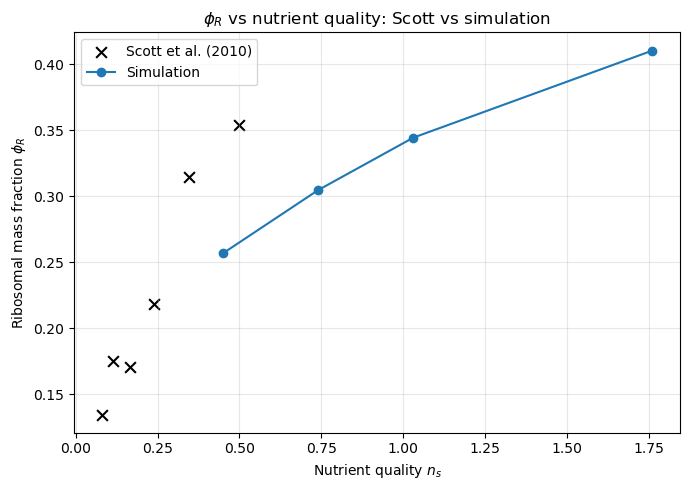

In [ ]:
import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.ipc as ipc
import matplotlib.pyplot as plt
from scipy.stats import linregress

# ---------- helpers ----------
def load_arrow(path):
    with pa.memory_map(path, "r") as src:
        return ipc.open_file(src).read_all().to_pandas()

FILES = {
    0.45: "ns045.arrow",
    0.74: "ns074.arrow",
    1.03: "ns103.arrow",
    1.76: "ns176.arrow",
}

# ---------- Scott data ----------
scott = pd.read_csv("Scott_Data.csv")
scott_no_abx = scott[scott["cl"] == 0].copy()

# If Scott file has an ns column, use it directly for x
if "ns" in scott_no_abx.columns:
    scott_ns = scott_no_abx["ns"].values
else:
    # fallback: just map their lambda onto an ns-like axis (not ideal)
    scott_ns = np.linspace(min(FILES.keys()), max(FILES.keys()), len(scott_no_abx))

scott_phiR = scott_no_abx["fr"].values    # ribosomal mass fraction from Scott

# ---------- Simulation: compute phi_R for each ns ----------
sim_ns = []
sim_phiR = []

for ns, fname in FILES.items():
    df = load_arrow(fname)

    # ribosomal proteins: free + all ribosome-bound species
    ribo = (df["r(t)"] + df["rmm(t)"] + df["rmt(t)"] +
            df["rmq(t)"] + df["rmr(t)"])
    # non-ribosomal proteins
    prot = df["et(t)"] + df["em(t)"] + df["q(t)"]+df["r(t)"]

    phi_t = ribo*58 / (ribo*58 + prot)          # instantaneous phi_R(t)
    phi_mean = phi_t.mean()               # time-average

    sim_ns.append(ns)
    sim_phiR.append(phi_mean)

sim_ns = np.array(sim_ns)
sim_phiR = np.array(sim_phiR)

# ---------- Plot: phi_R vs ns (no messing with ns!) ----------
plt.figure(figsize=(7,5))

# Scott experimental points at their ns coordinates
plt.scatter(scott_ns, scott_phiR, color="black", s=60, marker="x",
            label="Scott et al. (2010)")

# Simulation points at ns = 0.45, 0.74, 1.03, 1.76
order = np.argsort(sim_ns)
plt.plot(sim_ns[order], sim_phiR[order], "o-", color="tab:blue",
         label="Simulation")

plt.xlabel("Nutrient quality $n_s$")
plt.ylabel("Ribosomal mass fraction $\\phi_R$")
plt.title("$\\phi_R$ vs nutrient quality: Scott vs simulation")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


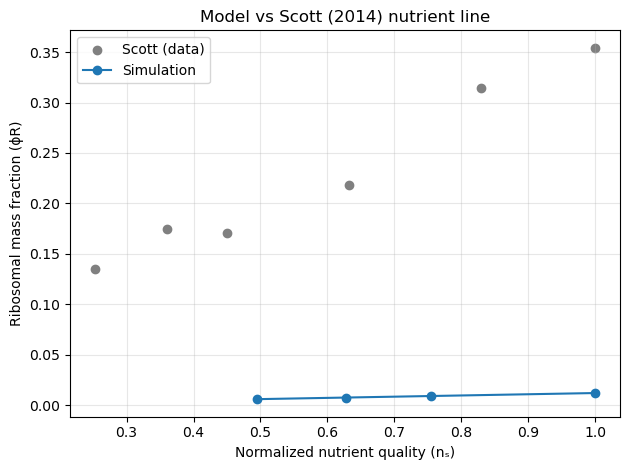

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters roughly consistent with Scott 2014
phi_min = 0.13
phi_max = 0.36
K_n = 0.3  # nutrient sensitivity (arbitrary; can adjust)

# Theoretical nutrient line
ns_theory = np.linspace(0, 1, 100)
phi_theory = phi_min + (ns_theory / (ns_theory + K_n)) * (phi_max - phi_min)

# Plot
# plt.figure(figsize=(7,5))
# plt.plot(ns_theory, phi_theory, "--", color="black", label="Scott 2014 theoretical nutrient line")
plt.scatter(scott_no_abx["ns_norm"], scott_no_abx["fr"], color="gray", label="Scott (data)")
plt.plot(sim_df["ns_norm_hat"], sim_df["phi_sim"], "o-", color="tab:blue", label="Simulation")
plt.xlabel("Normalized nutrient quality (nₛ)")
plt.ylabel("Ribosomal mass fraction (ϕR)")
plt.title("Model vs Scott (2014) nutrient line")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


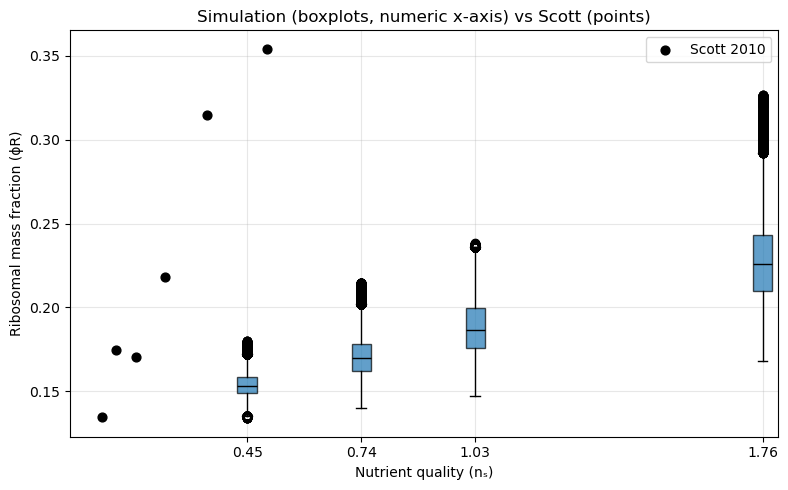

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pyarrow as pa
import pyarrow.ipc as ipc
import pandas as pd
import numpy as np

# === Utility to read Arrow file ===
def read_arrow(filename: str):
    with pa.memory_map(filename, "r") as source:
        return ipc.open_file(source).read_all().to_pandas()

# === Define your files with nutrient strengths ===
FILES_WITH_NS = [
    ("ns045.arrow", 0.45),
    ("ns074.arrow", 0.74),
    ("ns103.arrow", 1.03),
    ("ns176.arrow", 1.76)
]

# === Functions to compute total RNA & Protein ===
def total_rna(df):
    cols_rna = ["mr(t)", "mt(t)", "mm(t)", "mq(t)", 
                "rmr(t)", "rmt(t)", "rmm(t)", "rmq(t)",
                "zmr(t)", "zmt(t)", "zmm(t)", "zmq(t)"]
    return sum(df[c] for c in cols_rna if c in df.columns)

def total_protein(df):
    cols_prot = ["r(t)", "et(t)", "em(t)", "q(t)"]
    return sum(df[c] for c in cols_prot if c in df.columns)


# === Simulation parameters ===
BURN_IN_TIME = 1000   # adjust if needed
SCALE_FACTOR = 376      # from your previous fit

# === Collect steady-state samples ===
samples = []

for fname, ns in FILES_WITH_NS:
    df = read_arrow(fname)
    t = df["timestamp"].values
    mask = t >= BURN_IN_TIME  # steady-state only
    
    RNA = total_rna(df)[mask].values
    PROT = total_protein(df)[mask].values
    phiR = SCALE_FACTOR * RNA / PROT
    
    temp = pd.DataFrame({
        "ns": ns,
        "timestamp": t[mask],
        "RNA": RNA,
        "Protein": PROT,
        "phiR": phiR
    })
    samples.append(temp)

sim_samples = pd.concat(samples, ignore_index=True)
sim_samples.head()

scale_factor = 376  # from your previous fit

# Compute phi_R proxy for all simulation samples
sim_samples["phiR"] = scale_factor * sim_samples["RNA"] / sim_samples["Protein"]

# Add nutrient quality label
sim_samples["ns"] = sim_samples["ns"].astype(str)

# Get Scott data for drug-free conditions
scott_no_abx = scott[scott["cl"] == 0].copy()
scott_no_abx["phiR"] = scott_no_abx["fr"]  # rename for clarity
scott_no_abx["Source"] = "Scott 2010"

# Convert simulation ns back to float for numeric x-axis
sim_samples["ns"] = sim_samples["ns"].astype(float)

# Use Scott's actual ns values (not categories)
scott_no_abx["ns"] = scott_no_abx["ns"].astype(float)

plt.figure(figsize=(8,5))

# --- Simulation boxplots plotted on numeric x ---
for ns_value in sorted(sim_samples["ns"].unique()):
    subset = sim_samples[sim_samples["ns"] == ns_value]
    plt.boxplot(
        subset["phiR"],
        positions=[ns_value],
        widths=0.05,
        patch_artist=True,
        boxprops=dict(facecolor="tab:blue", alpha=0.7),
        medianprops=dict(color="black")
    )

# --- Scott points plotted at true ns ---
plt.scatter(
    scott_no_abx["ns"],
    scott_no_abx["phiR"],
    color="black",
    s=40,
    label="Scott 2010"
)

plt.xlim(0, 1.8)
plt.xlabel("Nutrient quality (nₛ)")
plt.ylabel("Ribosomal mass fraction (ϕR)")
plt.title("Simulation (boxplots, numeric x-axis) vs Scott (points)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

